In [1]:
!pip install pandas

In [2]:
import pandas as pd

df = pd.read_csv('2025_Airbnb_NYC_listings.csv')
print(df.head())

   Unnamed: 0     id       source  \
0           0  36121  city scrape   
1           1  36647  city scrape   
2           2  38663  city scrape   
3           3  38833  city scrape   
4           4  39282  city scrape   

                                                name  \
0                 Lg Rm in Historic Prospect Heights   
1  1 Bedroom & your own Bathroom, Elevator Apartment   
2                   Luxury Brownstone in Boerum Hill   
3                 Spectacular West Harlem Garden Apt   
4                    “Work-from-home” from OUR home.   

                                         description  \
0  Cozy space share in the heart of a great neigh...   
1  Private bedroom with your own bathroom in a 2 ...   
2  Beautiful, large home in great hipster neighbo...   
3  This is a very large and unique  space. An inc...   
4  *Monthly Discount will automatically apply <br...   

                               neighborhood_overview  host_id host_name  \
0  Full of tree-lined street

In [3]:
df = pd.read_csv('2025_Airbnb_NYC_listings.csv')

#price 숫자형으로 먼저 변환
df['price'] = df['price'].str.replace('$', '').str.replace(',', '').astype(float)

#A: 중요한 컬럼(이름, 호스트명, 가격)이 없는 행은 삭제
df_cleaned = df.dropna(subset=['name', 'price'])

#B: 너무 비어있는 컬럼(예: neighborhood_overview 등)은 컬럼 자체를 삭제 / 데이터의 50% 이상이 비어있는 컬럼 삭제
#df_cleaned = df_cleaned.dropna(thresh=len(df_cleaned)*0.5, axis=1)

#C: 숫자형 데이터 중 남은 결측치는 0으로 채우기
num = df_cleaned.select_dtypes(include=['number']).columns
df_cleaned[num] = df_cleaned[num].fillna(0)

print(f"처음 데이터 개수: {len(df)}")
print(f"결측치 제거 후 데이터 개수: {len(df_cleaned)}")
print(f"남은 컬럼 개수: {len(df_cleaned.columns)}")

#정제 데이터 확인
display(df_cleaned.head())

처음 데이터 개수: 22308
결측치 제거 후 데이터 개수: 22308
남은 컬럼 개수: 73


,Unnamed: 0,id,source,name,description,neighborhood_overview,host_id,host_name,host_since,host_location,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,0,36121,city scrape,Lg Rm in Historic Prospect Heights,Cozy space share in the heart of a great neigh...,Full of tree-lined streets and beautiful brown...,62165,Michael,2009-12-11,"New York, NY",...,5.00,5.00,5.00,NaN,f,1,0,1,0,0.05
1,1,36647,city scrape,"1 Bedroom & your own Bathroom, Elevator Apartment",Private bedroom with your own bathroom in a 2 ...,"Manhattan, SE corner of 2nd Ave/ E. 110th street",157798,Irene,2010-07-04,"New York, NY",...,4.90,4.38,4.71,NaN,f,1,0,1,0,0.58
2,2,38663,city scrape,Luxury Brownstone in Boerum Hill,"Beautiful, large home in great hipster neighbo...","diverse, lively, hip, cool: loaded with restau...",165789,Sarah,2010-07-13,"New York, NY",...,4.88,4.86,4.62,OSE-STRREG-0001784,f,1,0,1,0,0.28
3,3,38833,city scrape,Spectacular West Harlem Garden Apt,This is a very large and unique space. An inc...,West Harlem is now packed with great restauran...,166532,Matthew,2010-07-14,"New York, NY",...,4.96,4.79,4.82,OSE-STRREG-0000476,f,1,1,0,0,1.36
4,4,39282,city scrape,“Work-from-home” from OUR home.,*Monthly Discount will automatically apply <br...,THE NEIGHBORHOOD:<br />Our apartment is locate...,168525,Gustavo,2010-07-16,"New York, NY",...,4.88,4.85,4.78,OSE-STRREG-0001150,f,2,0,2,0,1.54


In [4]:
df = pd.read_csv('2025_Airbnb_NYC_listings.csv')

#숫자형 데이터인 컬럼만 골라내기
num_cols = df.select_dtypes(include=['number'])

#결측치(NaN) 개수 계산
na_counts = num_cols.isnull().sum()

#0인 값의 개수 계산
zero = (num_cols == 0).sum()

audit = pd.DataFrame({
    '결측치(NaN) 개수': na_counts,
    '0인 값 개수': zero
})

#값이 0보다 큰 것만
print(audit[ (audit['결측치(NaN) 개수'] > 0) | (audit['0인 값 개수'] > 0) ])

                                              결측치(NaN) 개수  0인 값 개수
Unnamed: 0                                              0        1
host_listings_count                                    20        0
host_total_listings_count                              20        0
bathrooms                                               6      434
bedrooms                                               49     2138
beds                                                   79      635
calendar_updated                                    22308        0
availability_30                                         0     5519
availability_60                                         0     3514
availability_90                                         0     2421
availability_365                                        0      168
number_of_reviews                                       0     6798
number_of_reviews_ltm                                   0    12234
number_of_reviews_l30d                                  0    1

In [5]:
#결측치가 왜 발생했는지?
df = pd.read_csv('2025_Airbnb_NYC_listings.csv')

#A : 수치형 데이터 중에서 0이나 결측치가 많은 컬럼 확인
# 리뷰 점수가 없는 숙소가 얼마나 있는지 확인
x_reviews = df['review_scores_rating'].isnull().sum()
print(f"리뷰 점수가 없는 숙소: {x_reviews}개")

#B : '리뷰 점수'가 없는 숙소들은 '리뷰 개수'도 0일까? (도메인 규칙 확인)
no_score = df[df['review_scores_rating'].isnull()]['number_of_reviews'].unique()
print(f"리뷰 점수 없는 숙소들의 리뷰 개수 종류: {no_score}")

#[0] : 점수가 없는 건 리뷰가 쌓이지 않아서

리뷰 점수가 없는 숙소: 6798개
리뷰 점수 없는 숙소들의 리뷰 개수 종류: [0]


뉴욕주 다세대 주택법 : 아파트 같은 다세대 주택(3세대 이상 거주 빌딩)의 경우, 집주인(호스트)이 함께 거주하지 않으면서 30일 미만으로 집 전체를 대여하는 것을 불법으로 규정함

그래서 많은 호스트가 실제로는 짧게 빌려도 데이터상에는 '30박'이라고 기입함

In [6]:
df = pd.read_csv('2025_Airbnb_NYC_listings.csv')

#30박 이상으로 설정된 숙소는 전체의 몇 %?
long_term = (df['minimum_nights'] >= 30).mean() * 100
print(f"\n최소 숙박일이 30박 이상인 숙소 비중: {long_term :.2f}%")


최소 숙박일이 30박 이상인 숙소 비중: 80.43%


30일 이상인 숙소가 80% 이상
이 데이터 분석으로 알 수 있는 인사이트 : 뉴욕 에어비앤비 시장이 '단기 여행자'를 위한 곳이 아니라 '중장기 체류자' 위주로 완전히 재편됐다.

어쩌면 80%의 호스트가 법(뉴욕주 다세대 주택법) 때문에 '30박'이라는 거짓말을 치고 있을 수도 있음

In [7]:
df['price'] = df['price'].str.replace('$', '', regex=False).str.replace(',', '', regex=False).astype(float)

expensive_listings = df[df['price'] >= 20000]
display_cols = ['name', 'neighbourhood_cleansed', 'room_type', 'price', 'number_of_reviews']

print(f"2만 달러 이상 숙소 개수: {len(expensive_listings)}개")
print("-" * 50)
print(expensive_listings[display_cols].sort_values(by='price', ascending=False))

2만 달러 이상 숙소 개수: 3개
--------------------------------------------------
                                     name neighbourhood_cleansed  \
14131       1-Bedroom Hotel Suite - 1 bed                   SoHo   
14132  2 Connecting Hotel Suites - 2 beds                   SoHo   
14133      1-Bedroom Hotel Suite - 2 beds                   SoHo   

          room_type    price  number_of_reviews  
14131  Private room  20000.0                  0  
14132  Private room  20000.0                  0  
14133  Private room  20000.0                  0  


In [8]:
df = pd.read_csv('2025_Airbnb_NYC_listings.csv')
print(f"제거 전 데이터 개수: {len(df)}")

df = df.dropna(subset=['has_availability'])
print(f"제거 후 데이터 개수: {len(df)}")

print(f"결측치 수: {df['has_availability'].isnull().sum()}")

제거 전 데이터 개수: 22308
제거 후 데이터 개수: 22062
결측치 수: 0


In [9]:
df['instant_bookable'].value_counts()

instant_bookable
f    16375
t     5687
Name: count, dtype: int64

In [10]:
df = pd.read_csv('2025_Airbnb_NYC_listings.csv')
print(f"제거 전 데이터 개수: {len(df)}")
df = df.dropna(subset=['instant_bookable'])

print(f"제거 후 데이터 개수: {len(df)}")

print(f"결측치 수: {df['instant_bookable'].isnull().sum()}")

제거 전 데이터 개수: 22308
제거 후 데이터 개수: 22308
결측치 수: 0


In [11]:
!pip install matplotlib
!pip install seaborn

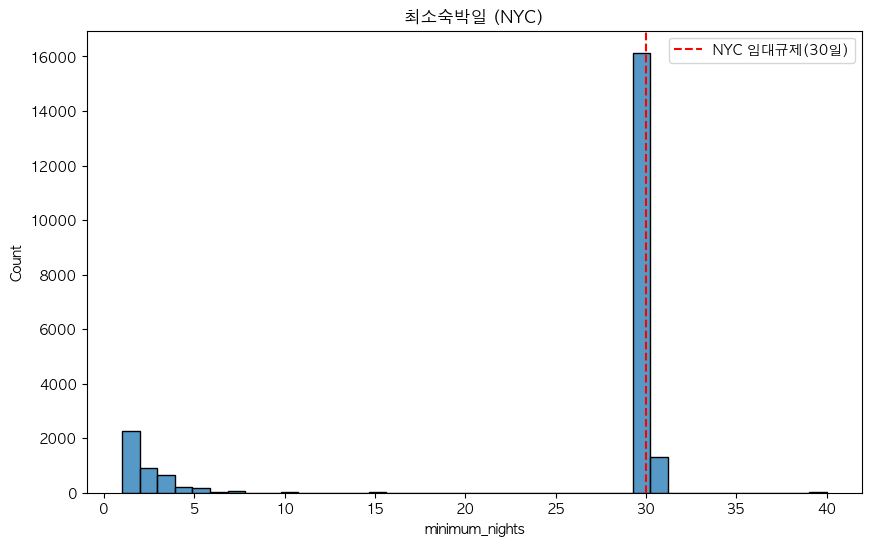

In [12]:
# 최소 숙박일수(minimum_nights) 분포 확인
df = pd.read_csv('2025_Airbnb_NYC_listings.csv')

import seaborn as sns
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'AppleGothic'  # Mac
# plt.rcParams['font.family'] = 'Malgun Gothic' # Windows
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(10, 6))
sns.histplot(df[df['minimum_nights'] <= 40]['minimum_nights'], bins=40)
plt.axvline(30, color='red', linestyle='--', label='NYC 임대규제(30일)')
plt.title('최소숙박일 (NYC)')
plt.legend()
plt.show()

--- 라이선스 보유 여부별 가격 통계 ---
  라이선스 여부    중앙값         평균값
0     미보유  130.0  197.040291
1      보유  182.0  280.988573


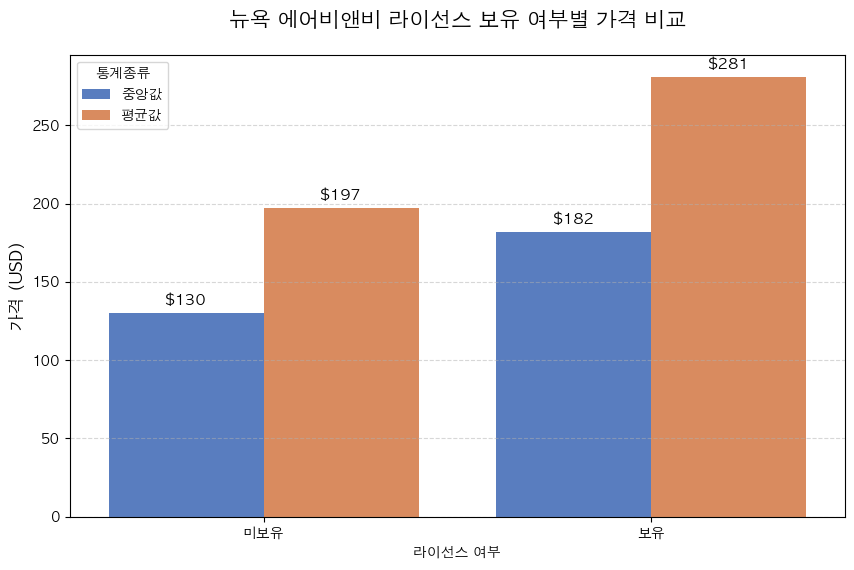

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'AppleGothic'  # Mac
# plt.rcParams['font.family'] = 'Malgun Gothic' # Windows
plt.rcParams['axes.unicode_minus'] = False

df['price'] = df['price'].astype(str).str.replace('$', '').str.replace(',', '').astype(float)

#라이선스 보유 여부 분류 ('license' 컬럼 활용)/값이 있다면(notna) '보유', 없으면 '미보유'
df['라이선스_여부'] = df['license'].apply(lambda x: '보유' if pd.notna(x) else '미보유')

#보유 여부별 중앙값과 평균값 계산
license_stats = df.groupby('라이선스_여부')['price'].agg(['median', 'mean']).reset_index()

license_stats.columns = ['라이선스 여부', '중앙값', '평균값']
print("--- 라이선스 보유 여부별 가격 통계 ---")
print(license_stats)

#시각화 (중앙값과 평균값을 동시에 비교)
df_melted = license_stats.melt(id_vars='라이선스 여부', var_name='통계종류', value_name='가격')

plt.figure(figsize=(10, 6))
sns.barplot(data=df_melted, x='라이선스 여부', y='가격', hue='통계종류', palette='muted')

plt.title('뉴욕 에어비앤비 라이선스 보유 여부별 가격 비교', fontsize=15, pad=20)
plt.ylabel('가격 (USD)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

#막대 위에 숫자 표시 (llm이 도와줬습니당^^)
for p in plt.gca().patches:
    height = p.get_height()
    if height > 0:
        plt.gca().text(p.get_x() + p.get_width()/2., height + 5,
                f'${height:,.0f}', ha='center', fontsize=11, fontweight='bold')

plt.show()

In [14]:
#상위 5개 데이터 확인
print(df['amenities'].head())

#데이터 타입 확인 (문자열인지 리스트인지)
print(type(df['amenities'].iloc[0]))

0    ["Refrigerator", "Dishes and silverware", "Wif...
1    ["Oven", "Blender", "Luggage dropoff allowed",...
2    ["Portable fans", "Oven", "Baking sheet", "Fir...
3    ["Fire extinguisher", "Clothing storage: close...
4    ["Oven", "Rice maker", "Laundromat nearby", "L...
Name: amenities, dtype: str
<class 'str'>


In [15]:
#어메니티 top30
list = df['amenities'].str.replace('[{}精彩\[\]"\']', '', regex=True).str.split(',')

flat_list = [item.strip() for sublist in list.dropna() for item in sublist]

import pandas as pd
print(pd.Series(flat_list).value_counts().head(30))

<>:2: SyntaxWarning: invalid escape sequence '\['
<>:2: SyntaxWarning: invalid escape sequence '\['
/var/folders/gl/8lvzdtwj3y16x6_c0dm1mj9c0000gn/T/ipykernel_10975/2389875217.py:2: SyntaxWarning: invalid escape sequence '\['
  list = df['amenities'].str.replace('[{}精彩\[\]"\']', '', regex=True).str.split(',')


Smoke alarm                   21096
Wifi                          20577
Carbon monoxide alarm         19386
Kitchen                       19122
Hot water                     17333
Essentials                    16548
Hangers                       16524
Hair dryer                    15354
Iron                          15268
Air conditioning              14922
Bed linens                    14873
Refrigerator                  14557
Dishes and silverware         14344
Cooking basics                14064
Microwave                     13865
Heating                       13707
Dedicated workspace           13073
TV                            12659
Shampoo                       11913
Self check-in                 11532
Fire extinguisher             11115
Long term stays allowed       10738
First aid kit                  9538
Coffee maker                   9444
Oven                           9374
Free street parking            9331
Extra pillows and blankets     8932
Bathtub                     

In [16]:
#자치구별 매물 수 현황
print(df['neighbourhood_group_cleansed'].value_counts())

neighbourhood_group_cleansed
Manhattan        10205
Brooklyn          7455
Queens            3420
Bronx              912
Staten Island      316
Name: count, dtype: int64


/var/folders/gl/8lvzdtwj3y16x6_c0dm1mj9c0000gn/T/ipykernel_10975/3175501943.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='neighbourhood_group_cleansed',


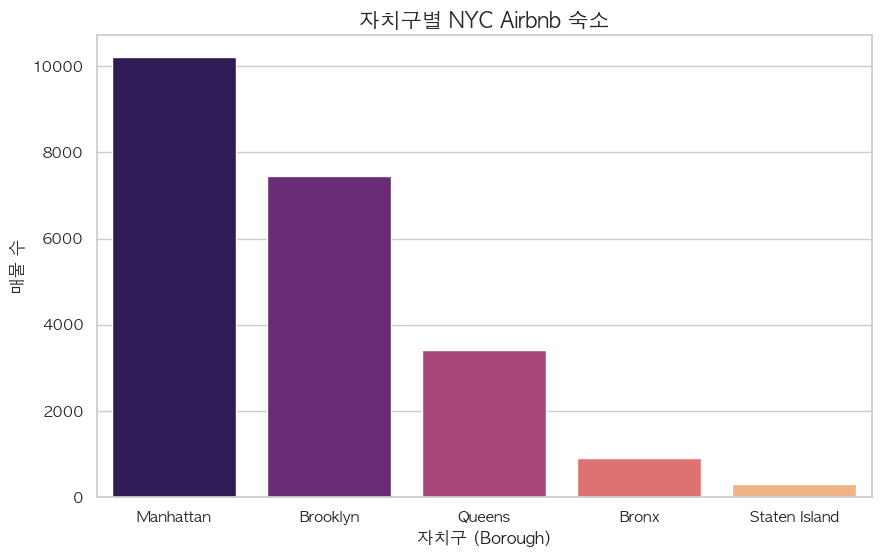

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rc('font', family='AppleGothic') 
plt.rc('axes', unicode_minus=False)

plt.figure(figsize=(10,6))
sns.set_theme(style="whitegrid", font="AppleGothic")

sns.countplot(data=df, x='neighbourhood_group_cleansed', 
              order=df['neighbourhood_group_cleansed'].value_counts().index,
              palette='magma')

plt.title('자치구별 NYC Airbnb 숙소', fontsize=15)
plt.xlabel('자치구 (Borough)', fontsize=12)
plt.ylabel('매물 수', fontsize=12)
plt.show()

In [18]:
#구별 평균 가격 정렬
df['price'] = df['price'].replace('[\$,]', '', regex=True).astype(float)

price_borough = df.groupby('neighbourhood_group_cleansed')['price'].mean().sort_values(ascending=False)
print(price_borough)

neighbourhood_group_cleansed
Manhattan        286.343557
Brooklyn         169.646680
Staten Island    128.344937
Queens           126.239474
Bronx            121.807018
Name: price, dtype: float64


<>:2: SyntaxWarning: invalid escape sequence '\$'
<>:2: SyntaxWarning: invalid escape sequence '\$'
/var/folders/gl/8lvzdtwj3y16x6_c0dm1mj9c0000gn/T/ipykernel_10975/1037430590.py:2: SyntaxWarning: invalid escape sequence '\$'
  df['price'] = df['price'].replace('[\$,]', '', regex=True).astype(float)


/var/folders/gl/8lvzdtwj3y16x6_c0dm1mj9c0000gn/T/ipykernel_10975/1215183720.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


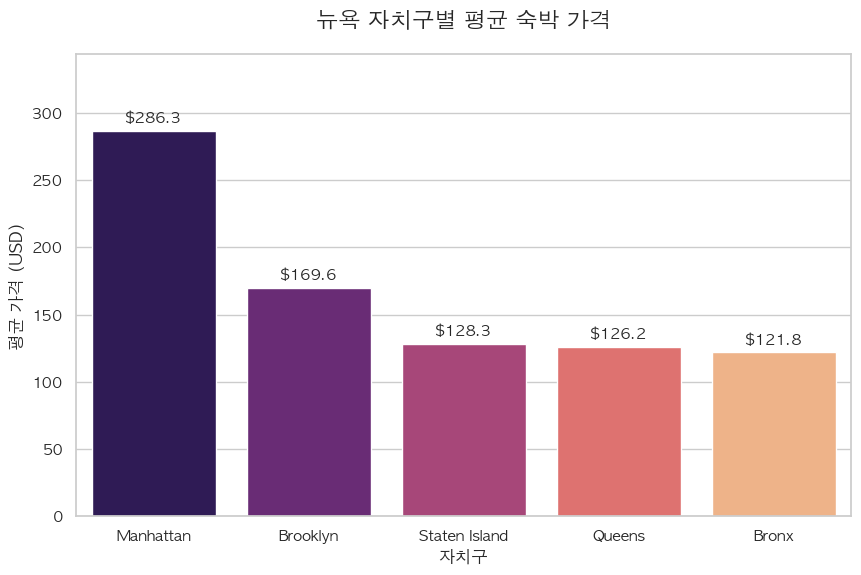

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rc('font', family='AppleGothic')
plt.rc('axes', unicode_minus=False)

#데이터 집계: 자치구별 평균 가격 계산
borough_price = df.groupby('neighbourhood_group_cleansed')['price'].mean().sort_values(ascending=False).reset_index()


plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid", font="AppleGothic")

#막대그래프
ax = sns.barplot(
    data=borough_price, 
    x='neighbourhood_group_cleansed', 
    y='price', 
    palette='magma'
)

#막대 위에 금액 표시 (llm이 도와줬습니당^^)
for p in ax.patches:
    ax.annotate(f'${p.get_height():.1f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points',
                fontsize=11, fontweight='bold')

plt.title('뉴욕 자치구별 평균 숙박 가격', fontsize=16, pad=20)
plt.xlabel('자치구', fontsize=12)
plt.ylabel('평균 가격 (USD)', fontsize=12)
plt.ylim(0, borough_price['price'].max() * 1.2) 
#막대그래프 위에 숫자 적을 공간을 확보하기 위해

plt.show()

자치구별 숙소 수를 봤을 때 Manhattan이 가장 많았는데, 역시 평균 가격도 가장 높았음.
하지만 Brooklyn과의 가격 차이가 생각보다 크지 않다면, 운영비가 저렴한 Brooklyn이 수익률 측면에서 더 유리할 수 있겠다고 생각할 수 있음.

-> 이 데이터를 통해 우리는 비싼 동네인 Manhattan에서 경쟁할지, 나름 가성비 동네라고 볼 수 있는 Brooklyn 에서 점유율을 높일지 결정해볼 수 있을 듯

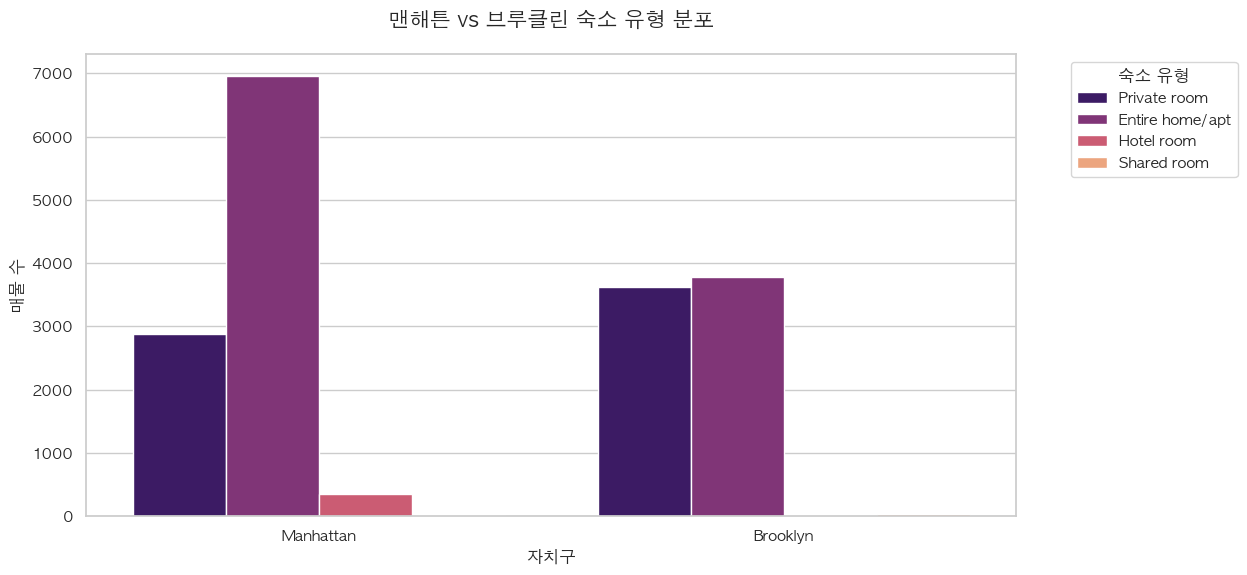

In [20]:
#그래프에 숙소유형이 다 안나와서 그 부분만 llm의 도움을 좀 받았습니다..^^

import matplotlib.pyplot as plt
import seaborn as sns

plt.rc('font', family='AppleGothic')

target_df = df[df['neighbourhood_group_cleansed'].isin(['Manhattan', 'Brooklyn'])]
room_types = df['room_type'].unique()

plt.figure(figsize=(12, 6))

sns.countplot(
    data=target_df, 
    x='neighbourhood_group_cleansed', 
    hue='room_type', 
    order=['Manhattan', 'Brooklyn'], 
    hue_order=room_types, #이 부분
    palette='magma' 
)

plt.title('맨해튼 vs 브루클린 숙소 유형 분포', fontsize=15, pad=20)
plt.xlabel('자치구', fontsize=12)
plt.ylabel('매물 수', fontsize=12)
plt.legend(title='숙소 유형', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

##### 자치구별 숙소 유형 분석

-> 맨해튼의 'Entire home' (오른쪽 그래프)
맨해튼은 집 전체(Entire home/apt) 비중이 압도적은 높음 (거의 7,000개)
반면 브루클린은 Entire home이랑 Private room(개인실) 비중이 거의 반반

-> 맨해튼은 집을 통째로 빌려주는? 비싼 숙소 위주라 평균가가 높을 수밖에 없다는 것을 알게됨 / 브루클린은 비교적 저렴한 개인실이 많아서 맨해튼의 평균 숙박 가격에 비해 낮다는 것을 알게됨

-> 브루클린에 개인실이 많은데도 평균이 $160를 넘는다는 건, 브루클린의 '집 전체' 가격으로 생각하면 맨해튼 못지않게 비싸다는 뜻 / 즉, 브루클린은 가성비 동네가 아니라 이미 맨해튼의 경쟁구?로 보아도 된다는 뜻

-> 맨해튼에만 보이는 hotel이 가격을 올리는 주범이라고 볼 수도 있겠음

만약에 우리가 추천을 해준다고 생각했을 때, 이런식으로 말해봐도 좋을 것 같음.
 
'맨해튼은 숙박업소의 공급량도 많고 평균적인 가격이 높지만, 그래프를 통해 보았을 때 전체대관 숙소나 호텔 위주의 공급 때문임'
'반면에 브루클린은 개인실 공급이 절반이더라도 높은 평균 가격을 유지함.'
'따라서 실질적 수익성..?을 고려해본다면, 개인실의 비중이 높아 운영부담금이 적으면서 가격방어 또한 잘되고 있는 브루클린이 전략적으로 유리하다.'

In [21]:
#숙소 유형별 가격 통계 요약
room_type_price_stats = df.groupby('room_type')['price'].describe()

#보고싶은 것만 : 평균, 표준편차, 최소, 25%, 중간, 75%, 최대
print(room_type_price_stats[['mean', 'std', 'min', '50%', 'max']])

                       mean         std   min    50%      max
room_type                                                    
Entire home/apt  265.344757  412.451932  16.0  190.0  15200.0
Hotel room       527.634409  527.342594   8.0  403.0   6563.0
Private room     130.763009  427.908249   7.0   81.0  20000.0
Shared room      144.662791  252.594379  14.0   79.0   2025.0


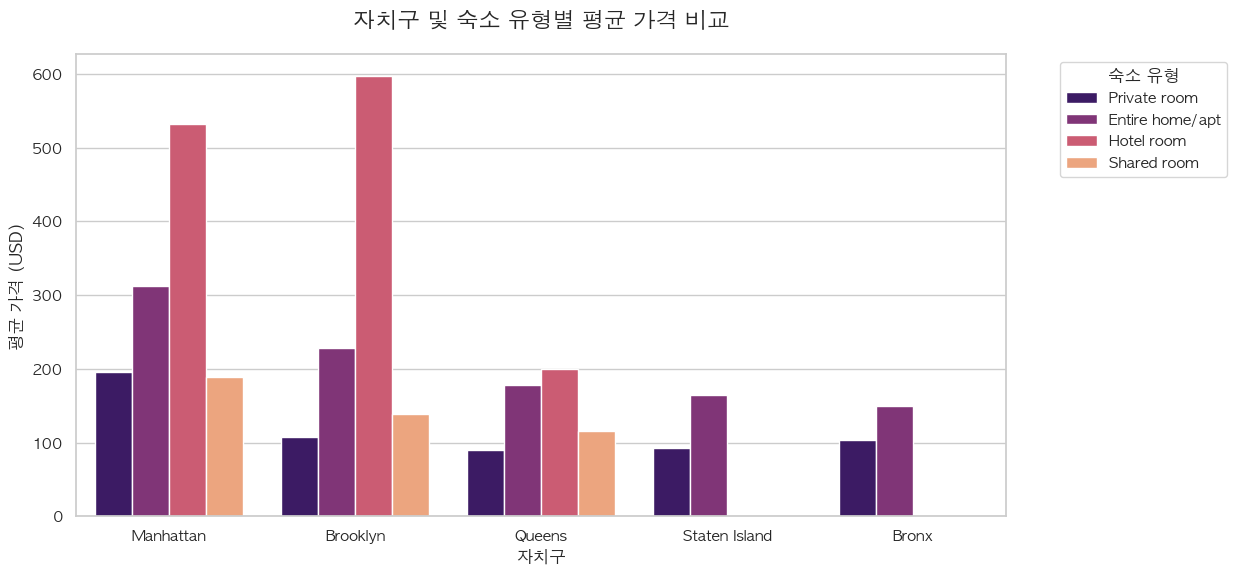

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.rc('font', family='AppleGothic')
plt.figure(figsize=(12, 6))

sns.barplot(
    data=df, 
    x='neighbourhood_group_cleansed', 
    y='price', 
    hue='room_type', 
    palette='magma',
    errorbar=None,
    order=['Manhattan', 'Brooklyn', 'Queens', 'Staten Island', 'Bronx'] 
)

plt.title('자치구 및 숙소 유형별 평균 가격 비교', fontsize=16, pad=20)
plt.xlabel('자치구')
plt.ylabel('평균 가격 (USD)')

plt.legend(title='숙소 유형', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [23]:
# 브루클린 호텔이 정확히 몇 개고 가격이 얼마인지 확인
brooklyn_hotels = df[(df['neighbourhood_group_cleansed'] == 'Brooklyn') & (df['room_type'] == 'Hotel room')]

print(f"브루클린 호텔 개수: {len(brooklyn_hotels)}개")
print(f"브루클린 호텔 가격들: \n{brooklyn_hotels['price'].values}")

브루클린 호텔 개수: 17개
브루클린 호텔 가격들: 
[184. 184. 184. 135. 344. 324. 799. 799. 799. 799. 799. 799. 799. 799.
 799. 799. 799.]


브루클린 호텔이 아까 숙소분포에서는 보이지 않았는데, 숙소유형별 가격비교를 해보니 호텔의 가격이 초고가로 잡혀서 데이터를 찾아보니까 17개가 나옴
17개 중에서 11개(약 65%)의 숙소가 799달러의 고가로 평균 가격이 맨해튼과 비슷한 수치가 나옴.
이 가격은 일반적인 시장가로 보기 보다는 특정 초고가 숙소에 의한 왜곡일 가능성이 높음.
그러므로 후에 전략 추천에서는 제외하는게 좋을 것 같음..?